# FLUJO 1
- Simulo los datos
- Analizo la data
- Construyo la data que le pasare al modelo


# 1. Imports y rutas

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import sys
from pathlib import Path

# ── Generadores de datos y contrato de artefactos (pipelines) ────────────────
from model_psbp_fd.pipelines import (
    ConfigEscenario2, generar_escenario_2, guardar_escenario,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)

# ── Preprocesamiento funcional (functions_models) ────────────────────────────
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)

# ── Evaluacion: lineas base sobre el bloque de prueba (fit) ──────────────────
from model_psbp_fd.fit import tabla_baselines

# ── Utilidades ───────────────────────────────────────────────────────────────
from model_psbp_fd.utils import get_project_root

# ── Visualizacion ────────────────────────────────────────────────────────────
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_functional_mean, plot_functional_variance,
    plot_mean_and_variance, plot_fts_empirical, plot_fts_functional,
    plot_scatter_theta, plot_functional_comparison,
    plot_diagnostico_estandarizacion, plot_fpca_scree,plot_seleccion_basis,
    plot_rezagos_heatmap
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

## 1.1 Constantes a modificar según experimento 

In [32]:
# Buscamos la raiz del proyecto
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT : {PROJECT_ROOT}")

BASENAME      = "escenario"
ESCENARIO_ID  = 2                          # Algoritmo 2 del anexo (FGARCH(1,1))
REPLICA_ID    = 1
SEED          = 41232
EXPERIMENT_ID = f"{BASENAME}_{ESCENARIO_ID}"     # formato de ruta sin cambios
print(f"Experiment ID : {EXPERIMENT_ID}")
print(f"Escenario     : {ESCENARIO_ID}   Replica : {REPLICA_ID}")
print(f"Seed (base)   : {SEED}")

PROJECT_ROOT : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
Experiment ID : escenario_2
Escenario     : 2   Replica : 1
Seed (base)   : 41232


## 1.2 Construccion de Rutas

In [33]:
# Construccion de rutas 
_REPORT_DIR = PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID
_ARTEFACT_DIR = PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,                         # Datos: raw + estandarizados
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,    # Coeficientes funcionales + FPCA
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,       # Datos predichos
    "out_report":   _REPORT_DIR,          # Figuras + métricas/config JSON
    "out_artefact": _ARTEFACT_DIR,        # Artefactos (serializados, por experimento)
}
for name, path in PATHS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"  {name:10s} → {path}")

  raw        → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_2
  functional → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_2
  predict    → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_2
  out_report → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_2
  out_artefact → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_2


# 2. Simulación

In [ ]:
# CONSTANTES DE LA SIMULACION — Escenario 2 (Algoritmo 2 del anexo)
#
#     X_t(tau)      = mu(tau) + sigma_t(tau) eta_t(tau)
#     sigma_t^2(tau) = delta(tau)
#                    + int beta(tau,s)  (X_{t-1}(s) - mu(s))^2 ds
#                    + int gamma(tau,s) sigma_{t-1}^2(s) ds
#
# La media condicional es constante e igual a mu: TODA la dependencia temporal
# reside en el segundo momento. Los metodos funcionales lineales, de innovacion
# homocedastica, no disponen de mecanismo para representar esta estructura.
#
# ─────────────────────────────────────────────────────────────────────────────
# POR QUE ESTOS VALORES Y NO LOS DEL CUADRO tab:escenarios
# ─────────────────────────────────────────────────────────────────────────────
# El termino ARCH no es (X_{t-1} - mu)^2 sino su PROMEDIO ESPACIAL ponderado por
# beta sobre una vecindad de ancho `alcance_beta`. Ese promedio cancela varianza:
# cuanto mas ancho el nucleo, mas se suaviza el shock y menos varia sigma^2. La
# consecuencia es que la intuicion del GARCH escalar NO se traslada, y los
# valores del Cuadro (masas 0.25 / 0.60, alcance 0.3) producen un proceso
# practicamente homocedastico: medido sobre este generador, CV(sigma^2) ~ 0.21 y
# acf1 de los residuos al cuadrado ~ 0.03, o sea indistinguible del Escenario 1.
#
# Para que el rasgo estructural EXISTA hay que compensar la cancelacion con una
# masa ARCH alta y un nucleo beta estrecho. De ahi los valores de abajo, elegidos
# por barrido sobre (persistencia, prop_arch, alcance_beta, ell) maximizando la
# heterocedasticidad VISIBLE A RESOLUCION GRUESA ---la del promedio de sigma^2
# sobre el dominio, que es la unica que un modelo con M chico puede aprovechar---
# sujeto a que la curtosis marginal no se dispare hasta volver el proceso una
# sucesion de valores atipicos aislados.
#
# [DIVERGENCIA CON docs/] Las masas efectivas resultantes son beta = 0.736 y
# gamma = 0.184, frente a las 0.25 / 0.60 del Cuadro. Es una divergencia
# DELIBERADA y debe reflejarse en el Cuadro del Capitulo 3 junto con su motivo.
#
# NOTA sobre la configuracion anterior: usaba prop_arch = 0.55 con
# persistencia = 0.85, o sea masa ARCH efectiva 0.4675. En terminos del GARCH
# escalar equivalente eso incumple la condicion de cuarto momento
# (p^2 + 2*alpha^2 = 1.16 > 1); el promedio espacial lo atenua y el proceso no
# diverge, pero la mezcla de masa ARCH alta con nucleo ancho (0.25) daba lo peor
# de ambos mundos: colas pesadas sin clustering visible.

def media_senoidal(tau):
    """mu(tau) = 5 + 2 sin(2 pi tau). Definida con nombre para que quede
    registrada de forma legible en simulation_config.json.

    NOTA: el Cuadro tab:escenarios fija mu(tau) = sin(2 pi tau). Se conserva la
    version con nivel 5 y amplitud 2 por continuidad con las corridas previas;
    es una traslacion afin que no afecta la dinamica ni los scores FPCA (que se
    centran), solo la escala visual de las figuras.
    """
    return 5.0 + 2.0 * np.sin(2.0 * np.pi * tau)

SIM_CFG = ConfigEscenario2(
    # -- Esquema de observacion --
    L         = 48,       # puntos de la grilla regular (valor del Cuadro)
    T         = 400,      # curvas retenidas; T0 = 320 deja 80 origenes de prueba
    burn_in   = 300,      # ~36 vidas medias del shock de varianza
    sigma_obs = 0.1,      # valor del Cuadro. CRITICO: el ruido de medicion es
                          # HOMOCEDASTICO y le suma una constante a la varianza
                          # de todos los periodos, comprimiendo el contraste
                          # calma/estres. Con 0.5 se perdia un tercio del rango.
    R         = 1,        # replicas (flujo 1: una; estudio Monte Carlo: 50)
    seed      = SEED,
    media_fn  = media_senoidal,
    # -- Recursion de varianza condicional --
    persistencia  = 0.92, # ||B + Gamma||_inf; vida media del shock ~8.3 periodos,
                          # que da ~10 episodios separados en los 80 origenes de
                          # prueba: suficientes para estratificar la cobertura.
    prop_arch     = 0.80, # fraccion de la persistencia atribuible a beta (ARCH).
                          # Alta a proposito: compensa la cancelacion por
                          # promedio espacial descrita arriba.
    alcance_beta  = 0.10, # ESTRECHO a proposito: menos promediado, mas varianza
                          # en sigma^2. Es el parametro mas sensible de los cuatro.
    alcance_gamma = 0.30, # persistencia de sigma^2; puede ser ancho sin dano
                          # porque actua sobre sigma^2, no sobre el cuadrado de
                          # la curva.
    var_objetivo  = 1.0,  # nivel estacionario de la varianza puntual
    # -- Innovacion funcional (correlacion; varianza puntual unitaria) --
    ell       = 0.4,      # longitud de correlacion. Valores altos hacen la
                          # innovacion espacialmente coherente, de modo que el
                          # promedio de beta cancela menos. El Cuadro fija 0.2;
                          # se conserva 0.4 de la configuracion previa por ese
                          # motivo, y es otra divergencia a declarar.
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<24}: {v}")

_masa_beta  = SIM_CFG.prop_arch * SIM_CFG.persistencia
_masa_gamma = SIM_CFG.persistencia - _masa_beta
print(f"\n  masa efectiva beta (ARCH)  : {_masa_beta:.3f}")
print(f"  masa efectiva gamma (GARCH): {_masa_gamma:.3f}")
print(f"  vida media del shock       : {np.log(0.5)/np.log(SIM_CFG.persistencia):.1f} periodos")

## 2.1 Simulación — Escenario 2: FGARCH(1,1) funcional (Algoritmo 2 del anexo)

La media condicional es constante ($\mu$) y la dependencia temporal vive
íntegramente en la varianza condicional $\sigma_t^2(\tau)$. El control de
calidad reporta, además de la condición de estacionariedad
$\rho(B+\Gamma)<1$, la evidencia de que el mecanismo está **activo**:
coeficiente de variación temporal de $\sigma^2$, exceso de curtosis marginal
y ACF a rezago 1 de los residuos al cuadrado.


In [35]:
# ── Generación mediante el Escenario 2 ───────────────────────────────────────
salida = generar_escenario_2(SIM_CFG)

# El flujo 1 analiza UNA réplica; el estudio Monte Carlo completo itera sobre R.
REPLICA_IDX = 0
X_raw = salida.observaciones[REPLICA_IDX]          # (T, L): matriz observada
T, G  = X_raw.shape

# Varianza condicional latente de esta réplica: INOBSERVABLE, uso exclusivo de
# diagnóstico. Nunca debe entrar al pipeline de estimación.
SIGMA2_LATENTE = salida.internos["sigma2"][REPLICA_IDX]    # (T, L)

# Alias de compatibilidad: el resto del notebook usa `domain.grid`
from types import SimpleNamespace
domain = SimpleNamespace(grid=salida.grilla)

print(f"Datos simulados : {X_raw.shape}  →  T={T} curvas, G={G} puntos")
print("Control de calidad del generador:")
for k, v in salida.diagnostico.items():
    print(f"  {k:30s} = {v}")

# ── Guardar configuración de simulación y grilla ─────────────────────────────
# La grilla y las curvas se persisten juntas en el paso funcional
# mediante guardar_curvas (contrato de artefactos).

simulation_config = {
    "sim_params":    salida.config.to_dict(),
    "diagnostico":   salida.diagnostico,
    "replica_idx":   REPLICA_IDX,
    "experiment_id": EXPERIMENT_ID,
    "seed":          SEED,
    "T":             int(T),
    "G":             int(G),
}
with open(PATHS["raw"] / "simulation_config.json", "w", encoding="utf-8") as _f:
    json.dump(simulation_config, _f, indent=2, ensure_ascii=False)

# Persistencia completa del escenario (todas las réplicas, formato .npz)
_npz = guardar_escenario(salida, str(PATHS["raw"] / "escenario_2"),
                         incluir_curvas=True, incluir_internos=True)

print(f"[raw] domain_grid.npy  ({domain.grid.shape})  → {PATHS['raw']}")
print(f"[raw] simulation_config.json             → {PATHS['raw']}")
print(f"[raw] escenario_2.npz (salida completa)  → {_npz}")


Datos simulados : (300, 70)  →  T=300 curvas, G=70 puntos
Control de calidad del generador:
  n_replicas                     = 1
  n_curvas                       = 300
  n_puntos_grilla                = 70
  todo_finito                    = True
  media_empirica_global          = 4.961092638049222
  media_ee_montecarlo            = nan
  var_puntual_media              = 0.6887171146029105
  var_puntual_min                = 0.6302476337873393
  var_puntual_max                = 0.7420320590191353
  acf1_media                     = -0.0700155342522059
  acf1_ee_montecarlo             = nan
  razon_senal_ruido              = 2.754868458411642
  persistencia_objetivo          = 0.85
  norma_inf_BG                   = 0.8499999999999998
  persistencia_error_absoluto    = 2.220446049250313e-16
  radio_espectral_BG             = 0.7391883612996534
  estacionariedad_garantizada    = True
  sigma2_finito                  = True
  sigma2_positivo                = True
  sigma2_min                

In [ ]:
# ── Diagnóstico de la heterocedasticidad condicional (control del generador) ─
# Este escenario existe para producir un segundo momento que varía con el
# estado. Si estas tres cifras salen planas, el escenario es indistinguible del
# Escenario 1 y no discrimina entre métodos: hay que reconfigurar ANTES de
# gastar MCMC.
#
# Panel A: varianza condicional latente promediada sobre el dominio. Es la
#   cantidad que un modelo con M pequeño puede llegar a aprovechar; la versión
#   punto a punto sobrestima lo que el modelo ve si sigma^2 varía mucho entre
#   puntos del dominio.
# Panel B: su contraparte OBSERVABLE, la dispersión espacial de cada curva
#   respecto de la media. Que A y B se parezcan es lo que garantiza que la
#   heterocedasticidad esté en los datos y no solo en el generador.
# Panel C: ACF de los residuos al cuadrado, el estadístico clásico de detección
#   de efectos ARCH.

_s2_dom  = SIGMA2_LATENTE.mean(axis=1)                       # (T,) sigma^2 medio
_disp_obs = (X_raw - salida.media[None, :]).std(axis=1)      # (T,) observable
_T0_prev  = int(np.floor(0.80 * T))
_umbral   = np.percentile(_s2_dom[:_T0_prev], 75)            # 'estrés' fijado en TRAIN
_n_estres = int((_s2_dom[_T0_prev:] > _umbral).sum())

_Y = X_raw - X_raw.mean(axis=0, keepdims=True)
_z = (_Y ** 2).mean(axis=1); _z = _z - _z.mean()
_acf = np.array([1.0] + [float(np.sum(_z[:-k] * _z[k:]) / np.sum(_z ** 2))
                         for k in range(1, 21)])

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(np.arange(1, T + 1), _s2_dom, color="#3b7dd8", lw=1.0)
axes[0].axhline(_umbral, color="#b5561f", ls="--", lw=1.4,
                label=f"umbral estrés (P75 train) = {_umbral:.2f}")
axes[0].axvline(_T0_prev, color="0.35", ls=":", lw=1.6, label=f"$T_0$ = {_T0_prev}")
axes[0].fill_between(np.arange(1, T + 1), _umbral, _s2_dom,
                     where=_s2_dom > _umbral, color="#e07b39", alpha=0.35)
axes[0].set_xlabel("t"); axes[0].set_ylabel(r"$\bar{\sigma}^2_t$")
axes[0].set_title("A. Varianza condicional latente (clustering)")
axes[0].legend(fontsize=7)

axes[1].plot(np.arange(1, T + 1), _disp_obs, color="#4ca64c", lw=1.0)
axes[1].axvline(_T0_prev, color="0.35", ls=":", lw=1.6)
axes[1].set_xlabel("t"); axes[1].set_ylabel(r"$\mathrm{sd}_\tau(X_t - \mu)$")
axes[1].set_title("B. Dispersión observable por curva")

axes[2].bar(np.arange(len(_acf)), _acf, color="#c9c9c9")
axes[2].bar([1], [_acf[1]], color="#e07b39")
axes[2].axhline(0, color="0.5", lw=1.0)
axes[2].axhline(1.96 / np.sqrt(T), color="#b5561f", ls="--", lw=1.2,
                label="banda 95 %")
axes[2].set_xlabel("rezago"); axes[2].set_ylabel("ACF")
axes[2].set_title("C. ACF de los residuos al cuadrado")
axes[2].legend(fontsize=7)

fig.suptitle("Escenario 2 — evidencia de heterocedasticidad condicional")
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "00_diagnostico_heterocedasticidad.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Cifras de control, con los umbrales bajo los cuales NO seguir ────────────
_cv    = float(_s2_dom.std() / _s2_dom.mean())
_p10, _p90 = np.percentile(_s2_dom, [10, 90])
_ratio = _p90 / _p10

print(f"CV temporal de sigma^2 (dominio)   : {_cv:.3f}    "
      + ("OK" if _cv > 0.8 else "← BAJO: apenas hay heterocedasticidad"))
print(f"razón P90/P10 de sigma^2           : {_ratio:.2f}     "
      + ("OK" if _ratio > 3.0 else "← BAJO: calma y estrés no se separan"))
print(f"acf(1) de residuos al cuadrado     : {_acf[1]:.3f}    "
      + ("OK" if _acf[1] > 0.25 else "← BAJO: efecto ARCH poco detectable"))
print(f"curtosis marginal (gaussiana = 3)  : {salida.diagnostico['curtosis_marginal']:.2f}     "
      + ("OK" if salida.diagnostico['curtosis_marginal'] < 12
         else "← ALTA: proceso dominado por atípicos aislados"))
print(f"razón señal/ruido de observación   : {salida.diagnostico['razon_senal_ruido']:.1f}")
print()
print(f"orígenes de prueba en 'estrés'     : {_n_estres} de {T - _T0_prev}    "
      + ("OK" if _n_estres >= 15 else "← POCOS: la cobertura condicional no tendrá potencia"))
print("  (umbral fijado con el P75 del bloque de ENTRENAMIENTO, de modo que la")
print("   estratificación del eje 2 no use información del período evaluado)")

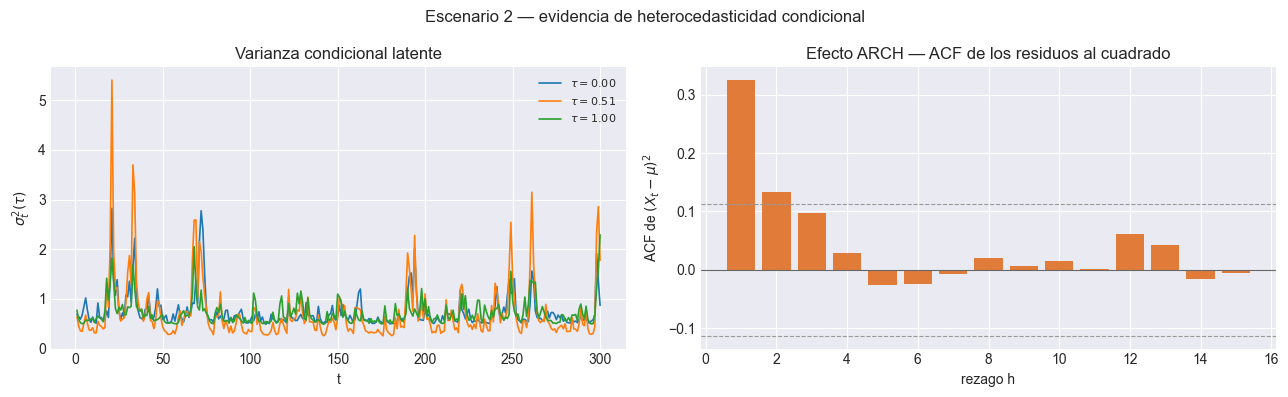

In [36]:
# ── Diagnóstico visual del mecanismo GARCH (latente, solo control) ───────────
_tau_idx = [0, G // 2, G - 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for j in _tau_idx:
    axes[0].plot(np.arange(1, T + 1), SIGMA2_LATENTE[:, j], lw=1.2,
                 label=rf"$\tau={domain.grid[j]:.2f}$")
axes[0].set_xlabel("t"); axes[0].set_ylabel(r"$\sigma_t^2(\tau)$")
axes[0].set_title("Varianza condicional latente")
axes[0].legend(fontsize=8)

_Y = salida.curvas[REPLICA_IDX] - salida.media[None, :]
_Z = _Y ** 2
_Z = _Z - _Z.mean(axis=0, keepdims=True)
_nlags = 15
_acf = [float(np.nanmean(np.sum(_Z[:-h] * _Z[h:], axis=0) / np.sum(_Z * _Z, axis=0)))
        for h in range(1, _nlags + 1)]
axes[1].bar(np.arange(1, _nlags + 1), _acf, color="#e07b39")
axes[1].axhline(0, color="0.4", lw=0.8)
for _s in (-1, 1):
    axes[1].axhline(_s * 1.96 / np.sqrt(T), color="0.6", ls="--", lw=0.8)
axes[1].set_xlabel("rezago h"); axes[1].set_ylabel(r"ACF de $(X_t-\mu)^2$")
axes[1].set_title("Efecto ARCH — ACF de los residuos al cuadrado")

fig.suptitle("Escenario 2 — evidencia de heterocedasticidad condicional")
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "00_diagnostico_fgarch.png", dpi=150,
            bbox_inches="tight")
plt.show()


## 2.2 Visualización de los datos empíricos

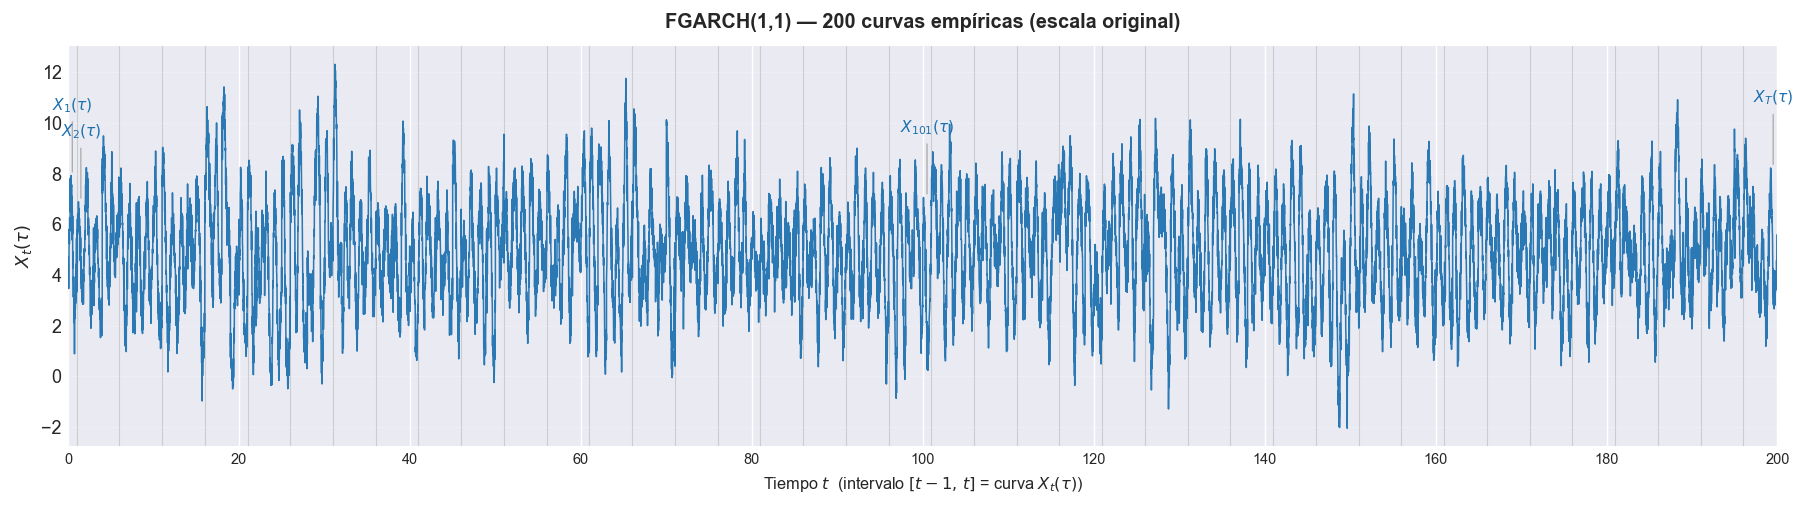

In [21]:
# ── Serie de tiempo funcional empírica (línea continua desplazada) ────────────
highlight_idx = [0, 1, T // 2, T - 1]

fig = plot_fts_empirical(
    X_raw, domain.grid,
    highlight_idx   = highlight_idx,
    title           = f"FGARCH(1,1) — {T} curvas empíricas (escala original)",
    separator_every = 5,
    save_path       = str(PATHS["out_report"] / "01_fts_empirica_raw.png"),
)
plt.show()

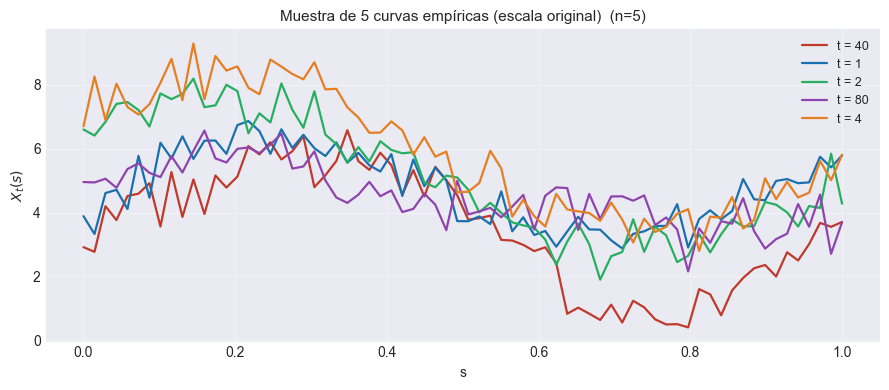

In [16]:
# ── Muestra de curvas empíricas (5 índices fijos) ─────────────────────────────
fig = plot_empirical_sample(
    X_raw, domain.grid,
    sample_idx = [40, 1, 2, 80, 4],
    title      = "Muestra de 5 curvas empíricas (escala original)",
    save_path  = str(PATHS["out_report"] / "02_muestra_empirica_raw.png"),
)
plt.show()

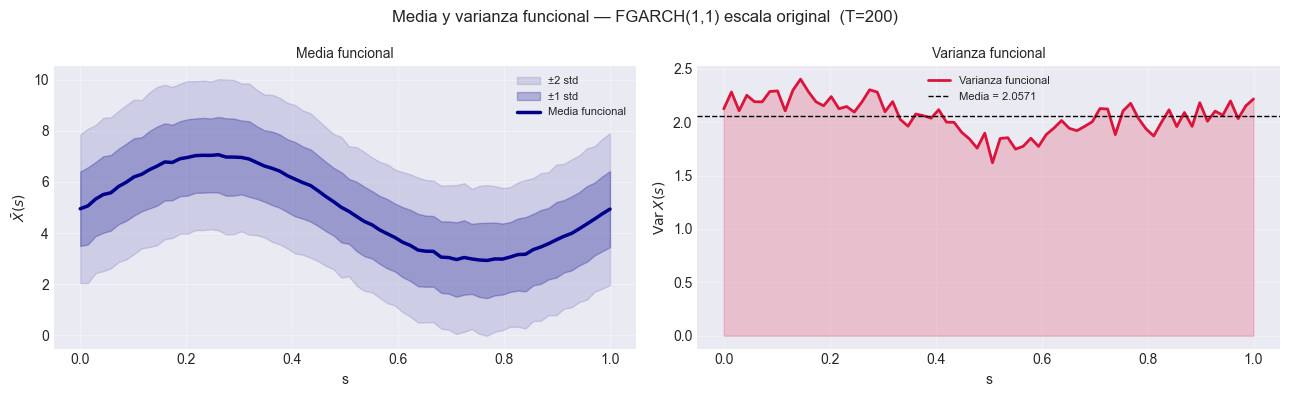

In [17]:
# ── Media y varianza funcional (panel combinado) ──────────────────────────────
fig = plot_mean_and_variance(
    X_raw, domain.grid,
    show_std1 = True,
    show_std2 = True,
    title     = "Media y varianza funcional — FGARCH(1,1) escala original",
    save_path = str(PATHS["out_report"] / "03_media_varianza_raw.png"),
)
plt.show()

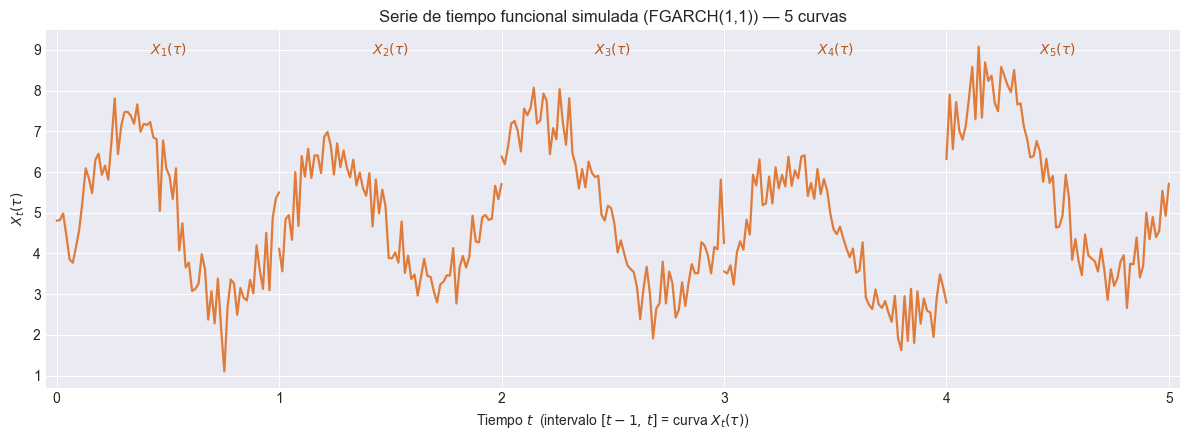

In [14]:
# ── 5 curvas como serie de tiempo (indexadas en t) — presentación ────────────
import numpy as np, matplotlib.pyplot as plt

n_dias = 5
X   = X_raw                                    # serie simulada (T, G); el alias 'X' también sirve
g   = np.asarray(domain.grid, dtype=float)
g01 = (g - g.min()) / (g.max() - g.min())      # dominio intra-curva normalizado a [0,1]

fig, ax = plt.subplots(figsize=(12, 4.5))
for i in range(n_dias):
    ax.plot(i + g01, X[i], color="#e07b39", lw=1.6)   # curva i ocupa el intervalo [i, i+1] en t

for i in range(n_dias + 1):                             # separadores
    ax.axvline(i, color="0.75", lw=0.8, zorder=0)
for i in range(n_dias):                                 # etiqueta por curva
    ax.text(i + 0.5, 0.97, f"$X_{{{i+1}}}(\\tau)$",
            transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=10, color="#b5561f")

ax.set_xlabel(r"Tiempo $t$  (intervalo $[t-1,\,t]$ = curva $X_t(\tau)$)")
ax.set_ylabel(r"$X_t(\tau)$")
ax.set_title("Serie de tiempo funcional simulada (FGARCH(1,1)) — 5 curvas")
ax.set_xticks(range(n_dias + 1))
ax.margins(x=0.01)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "pres_5_series_t_sim.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.3 Persistencia de datos crudos


In [15]:
X = X_raw   # alias para el resto del notebook (representación funcional sobre crudos)

# ── Persistencia de curvas y grilla (contrato de artefactos) ─────────────────
# guardar_curvas escribe X_curves.npy y domain_grid.npy en 'functional', que es
# donde el flujo de resultados los busca.
_p = guardar_curvas(PATHS, X, domain.grid)
print(f"[functional] X_curves.npy    {X.shape}")
print(f"[functional] domain_grid.npy {domain.grid.shape}")

[functional] X_curves.npy    (200, 70)
[functional] domain_grid.npy (70,)


## 2.4 Partición temporal de entrenamiento y prueba

La partición respeta el orden de la serie: todo objeto **estimado a partir de
los datos** (selección GCV de la base, FPCA, estandarizador) se ajusta
exclusivamente con el bloque inicial de entrenamiento $\{1,\dots,T_0\}$ y se
aplica al bloque de prueba $\{T_0+1,\dots,T\}$ mediante `transform`. El bloque
de prueba queda reservado para la evaluación fuera de muestra.

In [16]:
# ── Partición temporal (holdout) 
PROP_TRAIN = 0.80                          # proporción del bloque de entrenamiento
T0 = int(np.floor(PROP_TRAIN * T))         # nº de curvas de entrenamiento

assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train = np.arange(0, T0)               # t = 1 … T0      (0-based)
idx_test  = np.arange(T0, T)               # t = T0+1 … T
X_train, X_test = X[idx_train], X[idx_test]

print("Partición temporal (holdout):")
print(f"  entrenamiento : t ∈ [1, {T0}]      →  {X_train.shape}")
print(f"  prueba        : t ∈ [{T0+1}, {T}]  →  {X_test.shape}")
print(f"  proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

Partición temporal (holdout):
  entrenamiento : t ∈ [1, 160]      →  (160, 70)
  prueba        : t ∈ [161, 200]  →  (40, 70)
  proporción    : 80.0% / 20.0%


# 3. Representación funcional B-spline

In [17]:
# SELECCIÓN DE PARÁMETROS PARA EVALUAR LA REPRESENTACIÓN FUNCIONAL (n_basis, order)
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # [HOLDOUT] rango acotado por T0
ORDER_RANGE   = range(2, 5)
selection_records = []

for order_bs in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < order_bs:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=order_bs)
            TH_tmp = fr_tmp.fit_transform(X_train, domain.grid)   # [HOLDOUT] solo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]                            # puntos por curva
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)      # SSE_i(K)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            vr     = 1.0 - sse_c.sum() / ss_tot                  # VE(K)
            rmse_c = np.sqrt(sse_c / L_i)                        # e_i(K)
            df_k   = nb                                          # df(K) = n_basis
            gcv_c  = (L_i * sse_c / (L_i - df_k) ** 2            # GCV_i(K)
                      if L_i > df_k else np.full_like(sse_c, np.nan))

            selection_records.append({
                "n_basis": nb, "order": order_bs, "var_retained": vr,
                "rmse_mean": rmse_c.mean(), "rmse_max": rmse_c.max(),
                "gcv_mean": float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={order_bs}: {e}")

sel_df = pd.DataFrame(selection_records)

# ── Criterio: mínimo de GCV promedio sobre las curvas ─────────────────────
sel_valid = sel_df.dropna(subset=["gcv_mean"])
best_row  = sel_valid.loc[sel_valid["gcv_mean"].idxmin()]
nb_best   = int(best_row["n_basis"])
ord_best  = int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"],     cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn")
    .background_gradient(subset=["rmse_mean"],    cmap="YlOrRd_r"))

print(f"\nSelección por GCV mínimo: n_basis={nb_best}, order={ord_best}, "
      f"GCV={best_row['gcv_mean']:.6f}")
print(f"Verificación descriptiva: var_retained={best_row['var_retained']:.4%}, "
      f"rmse_mean={best_row['rmse_mean']:.6f}, rmse_max={best_row['rmse_max']:.6f}")


,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,-17.4548%,1.177006,1.905383,1.533060
1,3,2,-2.6575%,1.097457,1.739638,1.380217
2,4,2,69.6637%,0.606631,0.844888,0.420320
3,5,2,76.6043%,0.534721,0.664490,0.334207
4,6,2,79.3718%,0.502165,0.639243,0.303954
5,7,2,80.3191%,0.490508,0.624237,0.299274
6,8,2,80.9956%,0.482019,0.622316,0.298385
7,9,2,81.4432%,0.476268,0.633652,0.300989
8,10,2,81.8112%,0.471504,0.608361,0.304935
9,11,2,82.1363%,0.467340,0.610986,0.309723



Selección por GCV mínimo: n_basis=7, order=4, GCV=0.292935
Verificación descriptiva: var_retained=80.7360%, rmse_mean=0.485440, rmse_max=0.619613


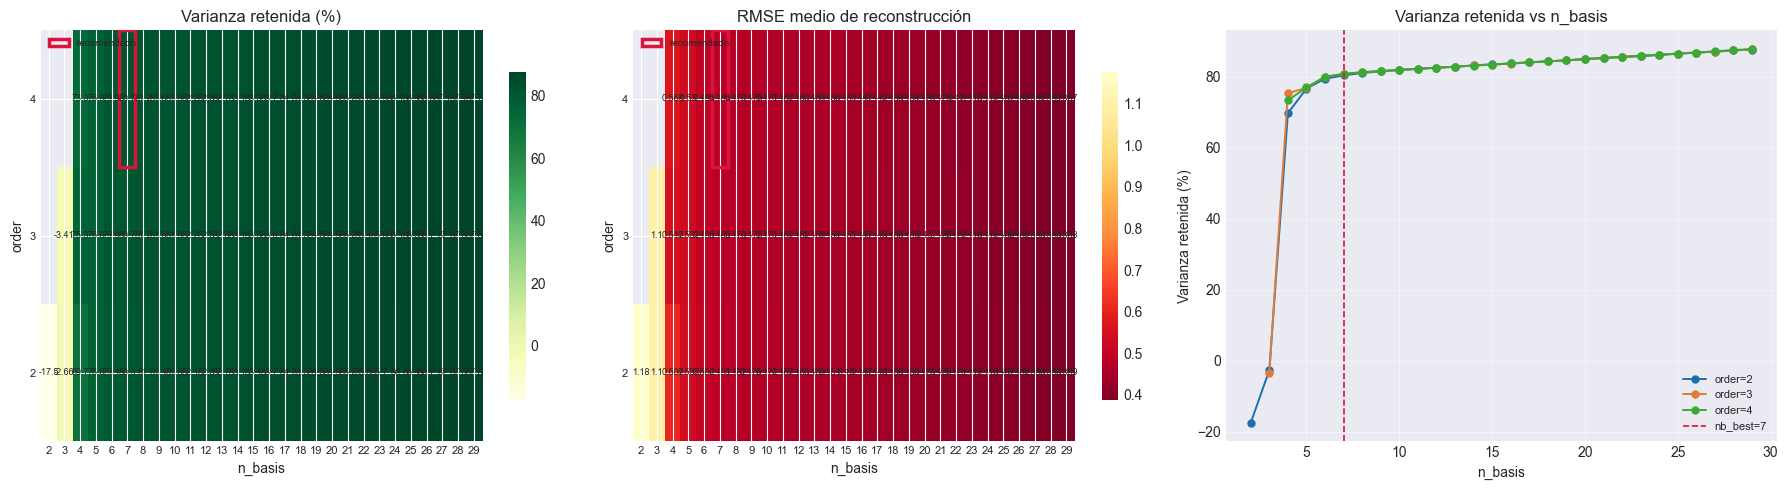

In [18]:
# ── Heatmaps + curva de varianza retenida ────────────────────────────────────
fig = plot_seleccion_basis(
    sel_df, nb_best, ord_best,
    save_path=str(PATHS["out_report"] / "08_seleccion_basis.png"),
)
plt.show()


## 3.1 Ajuste y visualización de la representación funcional

Base elegida  : n_basis=7, order=4
Sugerido GCV  : n_basis=7, order=4   (coinciden)
THETA shape: (200, 7)  (train=160, test=40)


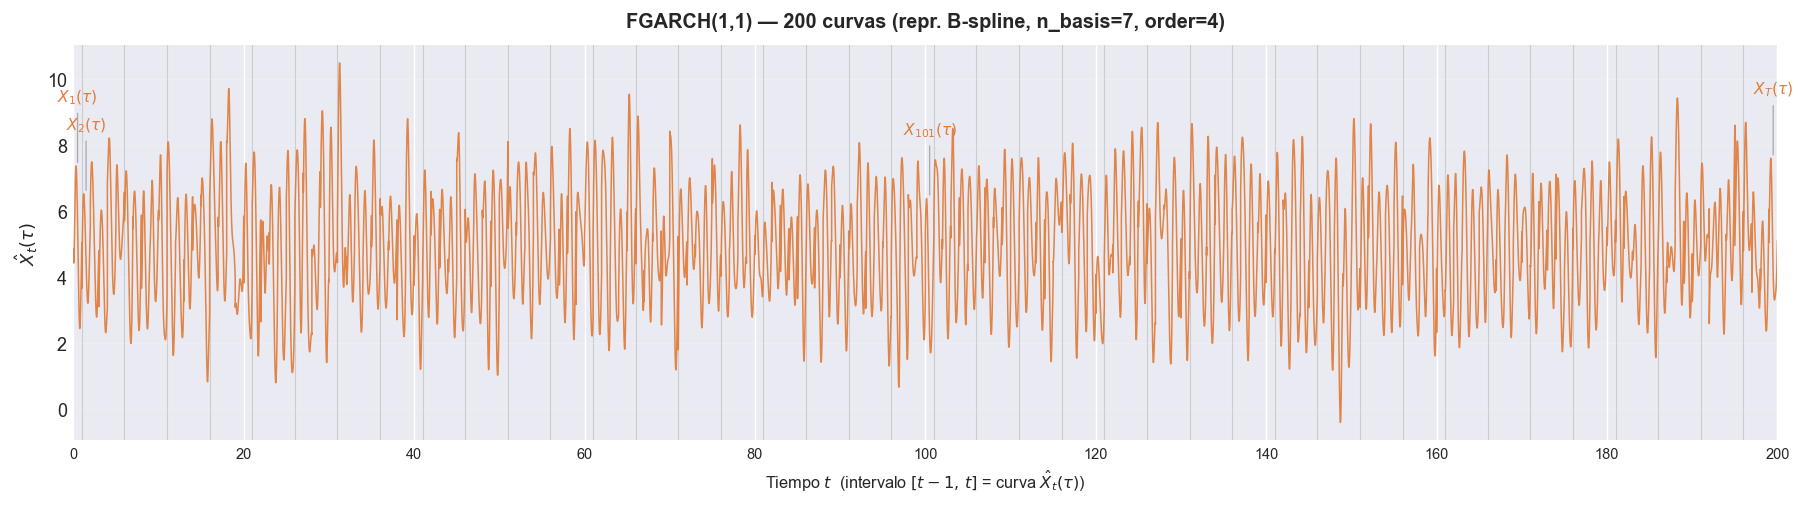

[functional] functional_representation.pkl + theta.csv + fr_config.json


In [19]:
# CONSTANTES ELEGIDAS PARA LA REPRESENTACIÓN FUNCIONAL
# La elección es una decisión del analista: el GCV de §3 la SUGIERE, no la fija.
# Se declaran en variables propias porque antes el objeto usaba (7, 4) mientras
# los títulos de las figuras mostraban (nb_best, ord_best), de modo que la
# figura documentaba una base distinta de la efectivamente ajustada.
NB_ELEGIDO  = 7
ORD_ELEGIDO = 4
print(f"Base elegida  : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV  : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

# center=False es imprescindible y por eso se declara de forma explicita. Con
# center=True, `reconstruct` es el mapa AFIN Theta Phi^T + media en lugar del
# lineal, y la funcion media contamina la base recuperada por `base_en_grilla`,
# la matriz de Gram y las autofunciones. `FPCA_L2.verificar(fr=fr)` lo detecta
# en §3.2, pero conviene no llegar hasta ahi.
fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)


# [HOLDOUT] Ajuste SOLO con entrenamiento; proyección de toda la serie.
# Para B-splines la base depende únicamente de la grilla, pero se mantiene la
# disciplina fit/transform para que el patrón sea válido con cualquier método.
fr.fit(X_train, domain.grid)
THETA       = fr.transform(X, domain.grid)            # (T, K)  serie completa
THETA_train = THETA[idx_train]                        # (T0, K)
print(f"THETA shape: {THETA.shape}  (train={THETA_train.shape[0]}, test={T - T0})")

# ── Serie de tiempo funcional con representación B-spline ────────────────────
fig = plot_fts_functional(
    X, domain.grid,
    fr              = fr,
    highlight_idx   = highlight_idx,
    title           = f"FGARCH(1,1) — {T} curvas (repr. B-spline, n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})",
    separator_every = 5,
    save_path       = str(PATHS["out_report"] / "09_fts_funcional_bspline.png"),
)
plt.show()

# ── Serializar la representación (contrato de artefactos) ────────────────────
guardar_representacion(PATHS, fr, THETA,
                       extra={"T0": int(T0), "prop_train": float(PROP_TRAIN),
                              "ajustado_en": "train", "center": bool(fr.center),
                              "n_basis": int(NB_ELEGIDO), "order": int(ORD_ELEGIDO),
                              "n_basis_gcv": int(nb_best), "order_gcv": int(ord_best)})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json")


## 3.2 Pasar la base selecionada a FPCA analizar cuantos componentes me quedare

Verificación FPCA_L2 (sobre entrenamiento):
  M                                  = 7
  K                                  = 7
  n_ajuste                           = 160
  cond_W                             = 2.778e+01
  err_ortonormalidad_L2              = 2.998e-15
  err_ortonormalidad_gram            = 2.887e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 1.776e-15
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 1.101e-15
  err_media_scores_rel               = 2.524e-15
  err_var_scores_vs_lambda           = 4.441e-16
  err_var_scores_vs_lambda_rel       = 2.241e-15
  err_correlacion_lag0               = 7.068e-15
  criterios_evaluados                = 7 criterios
  todo_ok                            = True

cond(W) = 2.778e+01  (condicionamiento sano)


,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,4.0308e-01,40.2595%,40.2595%,-0.089
1,2,3.2035e-01,31.9962%,72.2557%,-0.101
2,3,1.7012e-01,16.9918%,89.2475%,+0.029
3,4,6.3631e-02,6.3554%,95.6029%,+0.142
4,5,3.1196e-02,3.1158%,98.7187%,-0.064
5,6,8.1834e-03,0.8174%,99.5360%,-0.009
6,7,4.6454e-03,0.4640%,100.0000%,-0.106



K B-spline disponibles : 7
SUGERENCIA (var ≥ 95%) : M_SUGGERIDO = 4   ← solo referencia; fija M_FPCA en la celda 3.3


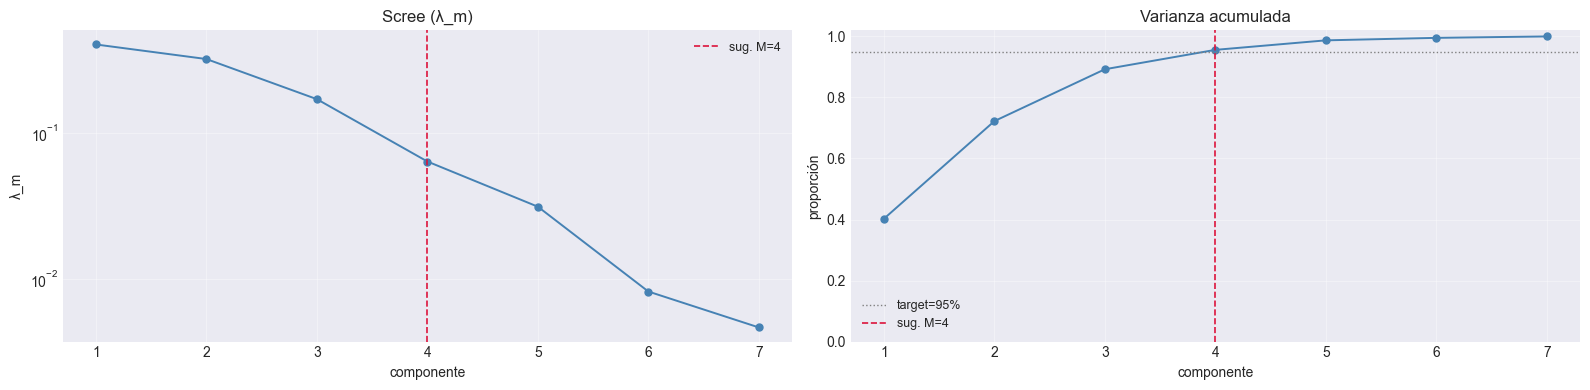

In [20]:
# FPCA GENERALIZADO en métrica L² (functions_models.FPCA_L2).
# Base B-spline NO ortonormal ⇒ Gram W = <φ_j,φ_k>_{L²} ≠ I, de modo que la
# descomposición correcta resuelve el problema propio generalizado
#     (W^{1/2} S_θ W^{1/2}) z = λ z,   con ‖ψ_m‖_{L²} = 1.
# [HOLDOUT] el ajuste emplea SOLO el bloque de entrenamiento.

Phi = base_en_grilla(fr, THETA.shape[1])          # (G, K): base en grilla
fpca = FPCA_L2().fit(THETA_train, Phi, domain.grid)

# ── Verificación de las identidades que sostienen la construcción ────────────
# `verificar` distingue ahora errores ADIMENSIONALES (ortonormalidad, rutas de
# reconstrucción) de errores en las UNIDADES de los datos (media y varianza de
# los scores), que se reportan además en forma relativa. El veredicto `todo_ok`
# se evalúa solo sobre los primeros y sobre las versiones relativas: mezclarlos
# hacía que el juicio dependiera de la amplitud de las curvas.
_ver = fpca.verificar(THETA_train, fr=fr)          # tol por defecto = 1e-10

print("Verificación FPCA_L2 (sobre entrenamiento):")
for _k, _v in _ver.items():
    if isinstance(_v, float):
        print(f"  {_k:34s} = {_v:.3e}")
    elif isinstance(_v, (list, tuple)):
        print(f"  {_k:34s} = {len(_v)} criterios")
    else:
        print(f"  {_k:34s} = {_v}")

# Condicionamiento de la matriz de Gram. La raíz inversa W^{-1/2} empleada en el
# ajuste amplifica el ruido de las direcciones asociadas a los autovalores
# menores de W, que son las de las componentes que después se truncan. Con
# bases muy solapadas o K grande el valor crece y conviene registrarlo para
# poder comparar escenarios con distinto K sin confundir una diferencia
# sustantiva con un artefacto numérico. Se persiste en fpca_meta.json.
_cond = _ver["cond_W"]
print(f"\ncond(W) = {_cond:.3e}", end="  ")
if _cond > 1e10:
    print("← MUY ALTO: reduzca n_basis o revise el solapamiento de la base")
elif _cond > 1e6:
    print("← alto: vigile las componentes de menor varianza")
else:
    print("(condicionamiento sano)")

assert _ver["todo_ok"], (
    "Las identidades del FPCA generalizado no se cumplen. Si falla "
    "`err_linealidad_reconstruct_rel`, revise que la representación se haya "
    "ajustado con center=False."
)

# ── Diagnóstico dinámico: AR(1) propio de cada componente (≠ varianza) ───────
# Varianza = representación; AR(1) = dinámica. Una FPC de var. baja puede tener
# AR fuerte (útil para pronóstico) y una de var. alta puede ser ruido temporal.
K = fpca.evals.size
_Bf = fpca.B_full
SCORES_all = (THETA_train - fpca.mu_theta) @ (fpca.W @ _Bf)   # (T0, K)
s0, s1 = SCORES_all[:-1], SCORES_all[1:]
ar1_own = (s1 * s0).sum(0) / np.clip((s0 * s0).sum(0), 1e-12, None)

evals, var_cum = fpca.evals, fpca.var_cum
VAR_TARGET  = 0.95   # CONSTANTE
M_SUGGERIDO = fpca.seleccionar_M(VAR_TARGET)

fpca_tbl = pd.DataFrame({
    "componente": np.arange(1, K + 1),
    "autovalor":  evals,
    "var_ratio":  fpca.var_ratio,
    "var_acum":   var_cum,
    "ar1_propio": ar1_own,
})
display(fpca_tbl.head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}", "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"}
).background_gradient(subset=["var_ratio"], cmap="YlGn")
 .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))
print(f"\nK B-spline disponibles : {K}")
print(f"SUGERENCIA (var ≥ {VAR_TARGET:.0%}) : M_SUGGERIDO = {M_SUGGERIDO}   "
      f"← solo referencia; fija M_FPCA en la celda 3.3")

fig = plot_fpca_scree(
    evals, var_cum, M_SUGGERIDO, var_target=VAR_TARGET,
    save_path=str(PATHS["out_report"] / "10_fpca_scree.png"),
)
plt.show()

## 3.3 Obtener el FPCA basado en la selecion

In [21]:
M_FPCA = 4   # ← nº de componentes FPCA a retener (lo fijas TÚ)

assert isinstance(M_FPCA, (int, np.integer)) and 1 <= M_FPCA <= fpca.evals.size, (
    f"M_FPCA debe ser entero en [1, {fpca.evals.size}]. Recibido: {M_FPCA!r}"
)
fpca.set_M(int(M_FPCA))
M_fpca = fpca.M

# ── Objetos derivados (compatibilidad con el resto del notebook) ─────────────
Psi_grid = fpca.Psi_grid          # (G, M) autofunciones ortonormales en L²
mu_grid  = fpca.mu_grid           # (G,)
W        = fpca.W                 # (K, K) Gram
B        = fpca.B                 # (K, M)
mu_theta = fpca.mu_theta          # (K,)

# [HOLDOUT] scores de TODA la serie proyectados sobre la base de entrenamiento
SCORES       = fpca.transform(THETA)          # (T, M)
SCORES_train = SCORES[idx_train]
SCORES_test  = SCORES[idx_test]

# ── Chequeo fuera de muestra: deriva entre bloques (estacionariedad §2.2.1) ──
print(f"M_fpca = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
print(f"[train] max|media ξ|  = {np.abs(SCORES_train.mean(0)).max():.2e}   (≈ 0)")
print(f"[test]  max|media ξ|  = {np.abs(SCORES_test.mean(0)).max():.3f}")
print(f"[test]  var ξ / λ     = "
      f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

# ── Persistencia FPCA: se pospone a §4.0 ────────────────────────────────────
# Antes esta celda escribía la FPCA sin SCORES_STD y §4.0 la reescribía con
# ellos. Ese doble guardado abría una ventana peligrosa: entre ambas celdas,
# `fpca_scores_std.csv` de una corrida anterior seguía en disco y `cargar_fpca`
# lo devolvía emparejado con scores nuevos, posiblemente con otro M. La escritura
# ocurre ahora una sola vez, en §4.0, cuando SCORES y SCORES_STD ya son
# mutuamente consistentes.
print("[nota] la FPCA se persiste en §4.0, junto con los scores estandarizados.")

M_fpca = 4   var. explicada = 95.6029%
[train] max|media ξ|  = 1.10e-15   (≈ 0)
[test]  max|media ξ|  = 0.218
[test]  var ξ / λ     = [0.766 0.872 0.847 1.381]
[nota] la FPCA se persiste en §4.0, junto con los scores estandarizados.


# 4. Construcción de datasets AR(p) sobre scores de FPCA (ecuación-por-ecuación)

## 4.0 Estandarización de scores ξ  **[FIX — punto de entrada al modelo]**

Los scores FPCA tienen varianza λₘ (heterogénea entre componentes:
λ₁ ≫ λ_M). Se estandarizan por columna (z-score, ddof=0) **antes** de
construir los datasets AR(p): respuesta y covariables entran al PSBP en
escala estandarizada. El estandarizador se persiste para que `02_03`
des-estandarice las predicciones antes de reconstruir curvas.

Nota: las correlaciones de rezagos (§4.1) son invariantes a esta
transformación lineal; se calculan sobre `SCORES_STD` por consistencia.

[holdout] estandarizador ajustado con 160 filas = T0 (train[1:160])  →  ok=True
Metodo: zscore_column
Features: 4
Filas de ajuste: 160  (train[1:160])
  Media: min=0.0000, max=0.0000
  Std:   min=0.2515, max=0.6329
SCORES_STD : shape=(200, 4)  (train=160, test=40)
  [train] max|media| = 1.29e-16  (≈ 0 por construcción)
  [train] max|std-1| = 3.33e-16  (≈ 0 por construcción)
  [test]  media      = [ 0.025  0.386  0.177 -0.049]
  [test]  std        = [0.867 0.925 0.912 1.164]
  std train por componente (=√λ_m): [0.633 0.564 0.411 0.251]
[functional] artefactos FPCA + fpca_scores_std.csv + scores_standardizer/
             cond_W persistido = 2.778e+01


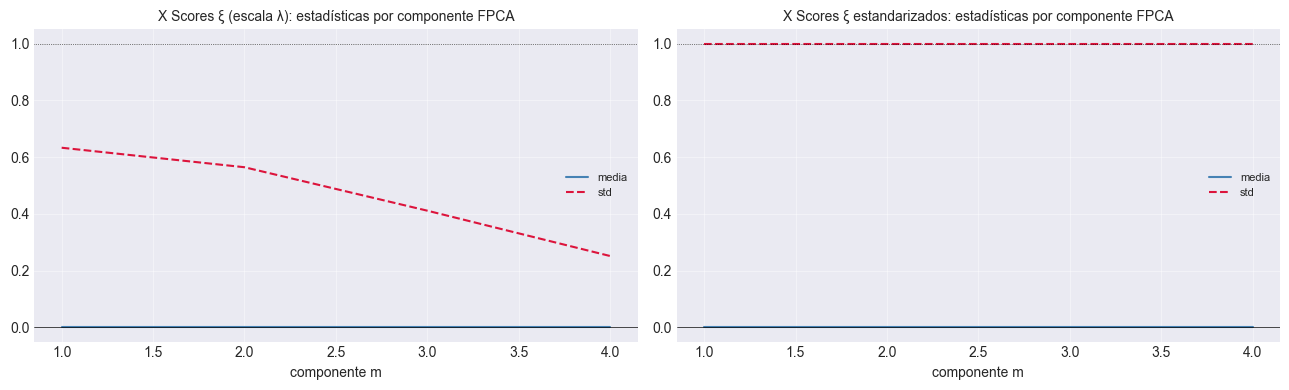

In [22]:
# [HOLDOUT] El ajuste emplea SOLO el bloque de entrenamiento. `etiqueta` y el
# registro interno `n_ajuste` convierten esa disciplina en una propiedad
# VERIFICABLE: antes la clase no guardaba rastro de con qué datos se había
# ajustado, de modo que un ajuste accidental sobre la serie completa producía
# números plausibles y resultados fuera de muestra inválidos, sin señal alguna.
scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

# Comprobación explícita: lanza excepción si el ajuste no corresponde a T0.
_chk_std = scores_standardizer.verificar_ajuste(T0)
print(f"[holdout] estandarizador ajustado con {_chk_std['n_ajuste']} filas "
      f"= T0 ({_chk_std['etiqueta_ajuste']})  →  ok={_chk_std['ajuste_ok']}")

SCORES_STD       = scores_standardizer.transform(SCORES)   # aplicado a toda la serie
SCORES_STD_train = SCORES_STD[idx_train]
SCORES_STD_test  = SCORES_STD[idx_test]

print(scores_standardizer.summary())
print(f"SCORES_STD : shape={SCORES_STD.shape}  (train={T0}, test={T - T0})")
print(f"  [train] max|media| = {np.abs(SCORES_STD_train.mean(0)).max():.2e}  (≈ 0 por construcción)")
print(f"  [train] max|std-1| = {np.abs(SCORES_STD_train.std(0) - 1).max():.2e}  (≈ 0 por construcción)")
print(f"  [test]  media      = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
print(f"  [test]  std        = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")
print(f"  std train por componente (=√λ_m): "
      f"{np.array2string(SCORES_train.std(axis=0), precision=3)}")

# ── Persistencia (contrato de artefactos) ────────────────────────────────────
# Escritura ÚNICA de la FPCA, ya con SCORES y SCORES_STD mutuamente
# consistentes. `guardar_fpca` persiste además cond_W en fpca_meta.json, y
# `guardar_estandarizador` escribe n_ajuste y etiqueta_ajuste en sus metadatos,
# que es lo que `verificar_contrato` cruza contra T0 en §6.
guardar_estandarizador(PATHS, scores_standardizer)
_res_fpca = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                         meta_extra={"T0": int(T0)})
print(f"[functional] artefactos FPCA + fpca_scores_std.csv + scores_standardizer/")
print(f"             cond_W persistido = {_res_fpca['meta']['cond_W']:.3e}")

# ── Diagnóstico visual (media/std por componente, antes y después) ───────────
fig = plot_diagnostico_estandarizacion(
    SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
    labels=("Scores ξ (escala λ)", "Scores ξ estandarizados"),
    title="estadísticas por componente FPCA",
    save_path=str(PATHS["out_report"] / "04_diagnostico_estandarizacion_scores.png"),
)
fig.axes[0].set_xlabel("componente m"); fig.axes[1].set_xlabel("componente m")
plt.show()


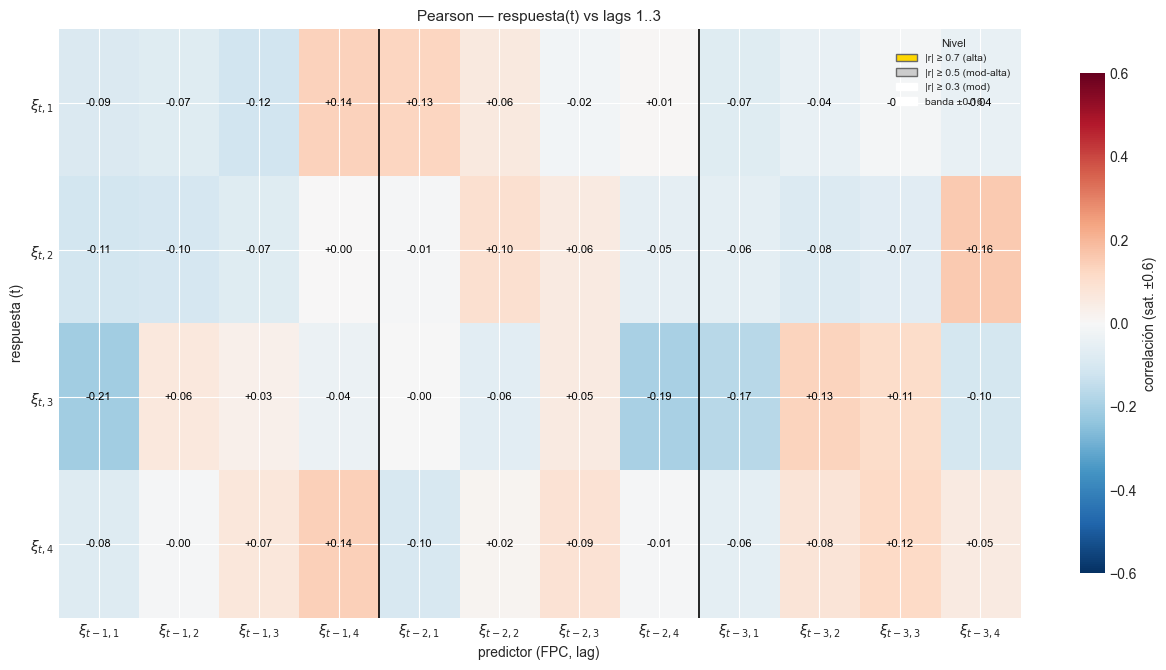

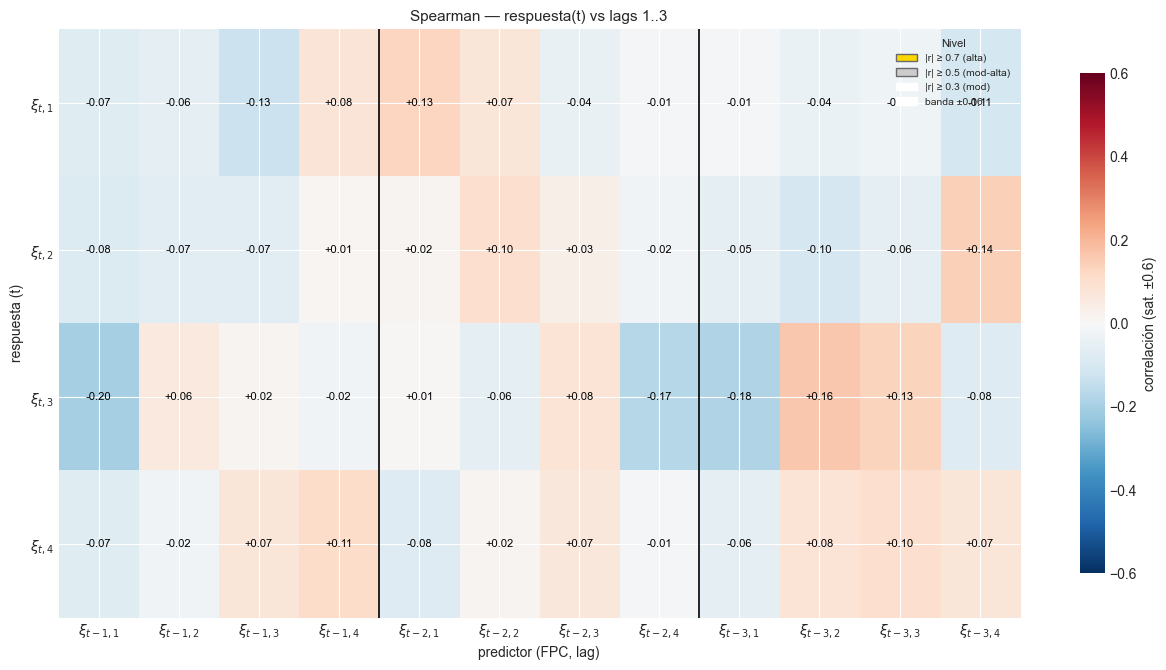

In [23]:
# [HOLDOUT] la elección de rezagos es una decisión de modelado: solo train
T_theta = SCORES_STD_train.shape[0]
K_total = SCORES_STD_train.shape[1]                          # nº de FPC disponibles (M)

# Lags de Diagnostico
N_LAGS_MAX = 3
N_LAGS_MAX = int(np.clip(N_LAGS_MAX, 1, T_theta - 2))

def _spearman_block(Y, X):
    """Spearman columna-a-columna vía rangos (pandas; sin scipy)."""
    Yr = pd.DataFrame(Y).rank().to_numpy()
    Xr = pd.DataFrame(X).rank().to_numpy()
    Yc = Yr - Yr.mean(0); Xc = Xr - Xr.mean(0)
    return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

# ── Matrices de correlación: respuesta (t) × predictor (FPC j, lag ℓ) ────────
n_cov = K_total * N_LAGS_MAX
corr_pearson  = np.zeros((K_total, n_cov))
corr_spearman = np.zeros((K_total, n_cov))
col_labels = []
y_block = SCORES_STD_train[N_LAGS_MAX:, :]                         # respuesta en t (alineada)

for lag in range(1, N_LAGS_MAX + 1):
    x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]   # predictores en t-lag
    sp = _spearman_block(y_block, x_block)
    for j in range(K_total):
        c = (lag - 1) * K_total + j
        for k in range(K_total):
            corr_pearson[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
        corr_spearman[:, c] = sp[:, j]
        col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
band  = 1.96 / np.sqrt(len(y_block))                     # banda de significancia (referencia)
VCLIP = 0.6

# ── Heatmaps de correlación ───────────────────────────────────────────────────
fig = plot_rezagos_heatmap(
    corr_pearson, col_labels, row_labels,
    title=f"Pearson — respuesta(t) vs lags 1..{N_LAGS_MAX}",
    n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=VCLIP,
    save_path=str(PATHS["out_report"] / "12a_rezagos_pearson.png"),
)
plt.show()

fig = plot_rezagos_heatmap(
    corr_spearman, col_labels, row_labels,
    title=f"Spearman — respuesta(t) vs lags 1..{N_LAGS_MAX}",
    n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=VCLIP,
    save_path=str(PATHS["out_report"] / "12b_rezagos_spearman.png"),
)
plt.show()


## 4.1 Selecion de lags y DATSET final 

In [24]:
N_LAGS  = 3
K_total = SCORES_STD.shape[1]        # nº de FPC disponibles (M)
COMPONENT_IDX = list(range(K_total))

# [HOLDOUT] tamaños efectivos por bloque
n_train_eff = T0 - N_LAGS            # respuestas en t = N_LAGS+1 … T0
n_test_eff  = T - T0                 # respuestas en t = T0+1 … T (rezagos desde train)

assert T0 > N_LAGS, f"T0={T0} debe superar N_LAGS={N_LAGS}."

print(f"K_total disponibles : {K_total}  (índices 0 … {K_total - 1})")
print(f"T / T0              : {T} / {T0}")
print(f"N_LAGS              : {N_LAGS}")
print(f"n_train_eff         : {n_train_eff}")
print(f"n_test_eff          : {n_test_eff}")

K_total disponibles : 4  (índices 0 … 3)
T / T0              : 200 / 160
N_LAGS              : 3
n_train_eff         : 157
n_test_eff          : 40


In [25]:
# ── Validación ───────────────────────────────────────────────────────────────
assert len(COMPONENT_IDX) > 0, "COMPONENT_IDX no puede estar vacío."
assert len(COMPONENT_IDX) == len(set(COMPONENT_IDX)), "COMPONENT_IDX tiene índices repetidos."
assert all(0 <= i < K_total for i in COMPONENT_IDX), (
    f"Todos los índices deben estar en [0, {K_total - 1}]. Recibido: {COMPONENT_IDX}"
)

n_components = len(COMPONENT_IDX)

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f"K_total disponibles : {K_total}")
print(f"Componentes usados  : {n_components}  →  índices {COMPONENT_IDX}")
print(f"Orden AR (N_LAGS)   : {N_LAGS}")
print()
print(f"  {'k_modelo':>8}  {'idx_THETA':>10}  {'nombre_resp':>14}")
print(f"  {'─'*8}  {'─'*10}  {'─'*14}")
for k_model, idx in enumerate(COMPONENT_IDX):
    print(f"  {k_model:>8}  {idx:>10}  {'fpc_' + str(idx + 1):>14}")

K_total disponibles : 4
Componentes usados  : 4  →  índices [0, 1, 2, 3]
Orden AR (N_LAGS)   : 3

  k_modelo   idx_THETA     nombre_resp
  ────────  ──────────  ──────────────
         0           0           fpc_1
         1           1           fpc_2
         2           2           fpc_3
         3           3           fpc_4


In [26]:
# ── Construcción de DataFrames AR(p): bloques de entrenamiento y prueba ──────
SCORES_sel = SCORES_STD[:, COMPONENT_IDX]   # (T, n_components) estandarizados

cov_names = [
    f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
    for lag in range(1, N_LAGS + 1)
    for j in range(n_components)
]

def _dataset_bloque(k: int, t_ini: int, t_fin: int) -> pd.DataFrame:
    """
    Filas con respuesta en t ∈ [t_ini, t_fin) y predictores en t-1 … t-N_LAGS.

    Los rezagos del primer origen de prueba provienen del final del bloque de
    entrenamiento: son observaciones pasadas disponibles en cada origen, de
    modo que su uso es el condicionamiento que prescribe §2.2.3.1 (predicción
    a horizonte h=1 con la historia observada), no fuga de información.
    """
    t_idx  = np.arange(t_ini, t_fin)
    y_col  = SCORES_sel[t_idx, k]
    X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
    return pd.DataFrame(np.column_stack([y_col, X_cols]),
                        columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

dfs_train, dfs_test = {}, {}
for k in range(n_components):
    dfs_train[k] = _dataset_bloque(k, N_LAGS, T0)     # (T0 - N_LAGS) filas
    dfs_test[k]  = _dataset_bloque(k, T0,     T)      # (T - T0) filas

dfs = dfs_train   # alias: el bloque de hiperparámetros itera sobre dfs

# ── Manifest + persistencia (contrato de artefactos) ─────────────────────────
manifest = {
    "scores_scale":  "standardized_zscore_ddof0",
    "n_components":  n_components,
    "n_lags":        int(N_LAGS),
    "component_idx": [int(i) for i in COMPONENT_IDX],
    "cov_names":     cov_names,
    "T":             int(T),
    "T0":            int(T0),
    "prop_train":    float(PROP_TRAIN),
    "n_train_eff":   int(n_train_eff),
    "n_test_eff":    int(n_test_eff),
    "ajuste_en":     "train",
}
guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
print(f"[functional] {2*n_components} datasets (train/test) + datasets_manifest.json")

[functional] 8 datasets (train/test) + datasets_manifest.json


# 5. Especificación de hiperparámetros y ajuste MCMC

In [27]:
MCMC_CONFIG = {"nsim": 2000, "burn": 500, "N": 20, "M": 50}
N_CHAINS    = 3
BURN        = int(MCMC_CONFIG["burn"])
print(f"MCMC_CONFIG : {MCMC_CONFIG}")
print(f"N_CHAINS    : {N_CHAINS}  (réplicas que ejecutará MATLAB)")


MCMC_CONFIG : {'nsim': 2000, 'burn': 500, 'N': 20, 'M': 50}
N_CHAINS    : 3  (réplicas que ejecutará MATLAB)


In [28]:
# ════════════════════════════════════════════════════════════════════════════
# HIPERPARÁMETROS — priors heterogéneas por tipo de variable
# ════════════════════════════════════════════════════════════════════════════

# ── Escalares globales ────────────────────────────────────────────────────────
HP_GLOBAL = {
    "atau":  2.0,
    "btau":  0.5,
    "ag":    2.0,
    "bg":    0.5,
    "mumu":  0.0,
    "taumu": 1.0,
    "pwj":   0.5,
}

# ── Priors por tipo de variable ───────────────────────────────────────────────
#   Formato: "tipo": (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0,  0.0, 1.0),   # E[π] = 0.90
    "cross_lag": (1.0, 1.0,  0.0, 1.0),   # E[π] = 0.50
}

# ── Clasificador ──────────────────────────────────────────────────────────────
def _classify(name: str, k_model: int, component_idx: list) -> str:
    own_name = f"fpc_{component_idx[k_model] + 1}_lag1"
    if name == own_name:
        return "own_lag1"
    if "_lag" in name:
        return "cross_lag"
    return "cross_lag"   # fallback: cualquier variable no reconocida → débil

# ── Construcción automática de HYPERPARAMS_LIST ───────────────────────────────
HYPERPARAMS_LIST = []
for k in range(n_components):
    p = len(cov_names)
    apij    = np.empty(p); bpij    = np.empty(p)
    mupsij  = np.empty(p); taupsij = np.empty(p)

    for j, name in enumerate(cov_names):
        vtype              = _classify(name, k, COMPONENT_IDX)
        a, b, mu, tau      = HP_BY_TYPE[vtype]
        apij[j]    = a;    bpij[j]    = b
        mupsij[j]  = mu;   taupsij[j] = tau

    HYPERPARAMS_LIST.append({**HP_GLOBAL,
                              "apij": apij,     "bpij": bpij,
                              "mupsij": mupsij, "taupsij": taupsij})

# ── Tabla de resumen ──────────────────────────────────────────────────────────
_W = 70
print("═" * _W)
print(f"  HYPERPARAMS_LIST  —  {n_components} componentes × {p} variables")
print("═" * _W)
print(f"  Globales: atau={HP_GLOBAL['atau']} btau={HP_GLOBAL['btau']}  "
      f"ag={HP_GLOBAL['ag']} bg={HP_GLOBAL['bg']}  "
      f"mumu={HP_GLOBAL['mumu']} taumu={HP_GLOBAL['taumu']}  "
      f"pwj={HP_GLOBAL['pwj']}")
print()
for k in range(n_components):
    hp = HYPERPARAMS_LIST[k]
    print(f"  Componente k={k+1}  (fpc_{COMPONENT_IDX[k]+1})")
    print(f"  {'Variable':<26} {'Tipo':<12} {'apij':>6} {'bpij':>6} "
          f"{'E[π]':>6} {'mupsij':>8} {'taupsij':>9}")
    print(f"  {'─'*26} {'─'*12} {'─'*6} {'─'*6} "
          f"{'─'*6} {'─'*8} {'─'*9}")
    for j, name in enumerate(cov_names):
        vtype = _classify(name, k, COMPONENT_IDX)
        a  = hp["apij"][j];    b  = hp["bpij"][j]
        mu = hp["mupsij"][j];  tau = hp["taupsij"][j]
        e_pi = a / (a + b)
        marker = "  ◄" if vtype == "own_lag1" else ""
        print(f"  {name:<26} {vtype:<12} {a:>6.1f} {b:>6.1f} "
              f"{e_pi:>6.3f} {mu:>8.1f} {tau:>9.1f}{marker}")
    print()

══════════════════════════════════════════════════════════════════════
  HYPERPARAMS_LIST  —  4 componentes × 12 variables
══════════════════════════════════════════════════════════════════════
  Globales: atau=2.0 btau=0.5  ag=2.0 bg=0.5  mumu=0.0 taumu=1.0  pwj=0.5

  Componente k=1  (fpc_1)
  Variable                   Tipo           apij   bpij   E[π]   mupsij   taupsij
  ────────────────────────── ──────────── ────── ────── ────── ──────── ─────────
  fpc_1_lag1                 own_lag1        9.0    1.0  0.900      0.0       1.0  ◄
  fpc_2_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_3_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_4_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_1_lag2                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_2_lag2                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_3_lag2                 cross_lag       1

In [29]:
# ── Guardar hiperparámetros del modelo en artefact ───────────────────────────

hp_artifact = {
    "global": HP_GLOBAL,
    "by_type": HP_BY_TYPE,
    "mcmc_config": MCMC_CONFIG,
    "n_iter": N_CHAINS,
    # [FIX] esquema real de semillas usado por psbp_fd_iteracion.m, con la
    # nomenclatura corregida (chain = cadena MCMC, k = componente FPCA).
    "seed_scheme": "SEED_BASE + chain*9973 + k*31",
    "escenario_id": int(ESCENARIO_ID),
    "replica_id": int(REPLICA_ID),
    "seed_base": SEED,
    "scores_scale": "standardized_zscore_ddof0",
    # [HOLDOUT] partición temporal — MATLAB entrena SOLO con *_train.csv
    "partition": {
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                        for k in range(n_components)],
        "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                        for k in range(n_components)],
    },
    "hyperparams_list": []
}

for k in range(n_components):
    hp = HYPERPARAMS_LIST[k].copy()
    hp_artifact["hyperparams_list"].append({
        "component_k": k,
        "fpc_idx": int(COMPONENT_IDX[k] + 1),
        "hyperparams": {
            key: value.tolist() if isinstance(value, np.ndarray) else value
            for key, value in hp.items()
        }
    })

guardar_hiperparametros(PATHS, hp_artifact)

print(f"✓ Hiperparámetros guardados en: {PATHS['out_artefact'] / 'hyperparameters.json'}")

✓ Hiperparámetros guardados en: C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\modelo_experimento_1_2\hyperparameters.json


# 6. Configuración de evaluación y líneas base (bloque de prueba)

Se persiste la configuración de evaluación (§2.2.3) que consumirá el flujo de
resultados, y se calculan **líneas base** sobre el bloque de prueba: el
predictor ingenuo de persistencia ($\hat\xi_t = \xi_{t-1}$) y la media
incondicional de entrenamiento ($\hat\xi_t = 0$ en escala estandarizada).
Ambas se evalúan a nivel de scores (RMSE) y a nivel de curva (MISE, RMSE
funcional), y constituyen el piso que todo modelo debe superar para justificar
su complejidad. No requieren MCMC, por lo que viven en este flujo.

In [30]:
# ── Configuración de evaluación (la consume el flujo de resultados) ──────────
eval_config = {
    "scheme":        "holdout_temporal",       # §2.2.3.1
    "T":             int(T),
    "T0":            int(T0),
    "prop_train":    float(PROP_TRAIN),
    "horizons":      [1],                       # h=1 vía dataset_test; h>1: simulación
    "n_lags":        int(N_LAGS),
    "metrics_scores": ["RMSE", "R2"],           # §2.2.3.2 sobre coeficientes
    "metrics_curvas": ["MISE", "RMSE_funcional"],
    "metrics_dist":   ["LPS", "CRPS", "cobertura_95", "PIT"],   # §2.2.3.3 (flujo 3)
    "scores_scale":  "standardized_zscore_ddof0",
}
guardar_config_evaluacion(PATHS, eval_config)
print(f"[out_artefact] eval_config.json")

# ── Líneas base sobre el bloque de prueba (h=1) ──────────────────────────────
# media incondicional (ξ̂=0) y persistencia (ξ̂_t = ξ_{t-1}), evaluadas a nivel
# de scores (RMSE, R²) y de curva (MISE, RMSE funcional) con fit.tabla_baselines.
baselines_df = tabla_baselines(
    SCORES_STD, T0,
    estandarizador=scores_standardizer,
    fpca=fpca,
    X_obs=X,
    tau=domain.grid,
    h=1,
)
baselines_df.to_csv(PATHS["out_report"] / "32_baselines_test.csv")
print(f"[out_report] 32_baselines_test.csv")
display(baselines_df.style.format("{:.4f}", na_rep="—")
        .set_caption("Líneas base — bloque de prueba, h=1 "
                     "(piso que el PSBP-FD debe superar)"))

# ── Verificación cruzada del contrato de artefactos ──────────────────────────
# Cruza manifest ↔ hyperparameters ↔ FPCA antes de pasar a MATLAB / flujo 3.
# `verificar_contrato` comprueba ahora, además, que el estandarizador
# persistido se haya ajustado con exactamente T0 filas. Si el artefacto en
# disco proviene de una corrida anterior al registro del bloque de ajuste, la
# verificación FALLA a propósito: sin ese dato la retención temporal no es
# auditable y los artefactos deben regenerarse.
informe = verificar_contrato(PATHS)
print(f"\ncontrato_ok = {informe['contrato_ok']}  "
      f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
      f"n_components={informe['n_components']})")
print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
      f"(T0 = {informe['T0']})")
print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")

[out_artefact] eval_config.json
[out_report] 32_baselines_test.csv


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,
media_incondicional,40.0000,0.8671,1.0023,0.9287,1.1652,0.9908,-0.0535,1.1047,1.0511
persistencia_lag1,40.0000,1.2705,1.1872,1.4047,1.6476,1.3775,-1.0430,1.8526,1.3611



contrato_ok = True  (M=4, K=7, T0=160, n_components=4)
estandarizador ajustado con 160 filas (T0 = 160)
verificación FPCA: todo_ok = True
